In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [2]:
class CustomEnv(gym.Env):
    def __init__(self):
        super(CustomEnv, self).__init__()
        self.observation_space = spaces.Box(low=0, high=100, shape=(1,), dtype=np.float32)
        self.action_space = spaces.Discrete(3)  # decrease, stay, increase
        self.state = 50.0

    def step(self, action):
        if action == 0:
            self.state -= random.uniform(0, 3)
        elif action == 2:
            self.state += random.uniform(0, 3)
        self.state = np.clip(self.state, 0, 100)

        reward = -abs(self.state - 70)
        terminated = reward > -1
        truncated = False
        return np.array([self.state], dtype=np.float32), reward, terminated, truncated, {}

    def reset(self, seed=None):
        super().reset(seed=seed)
        self.state = random.uniform(30, 60)
        return np.array([self.state], dtype=np.float32), {}


In [3]:
class DQNAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQNAgent, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.net(x)


In [4]:
env = CustomEnv()
agent = DQNAgent(1, 3)
optimizer = optim.Adam(agent.parameters(), lr=0.001)
criterion = nn.MSELoss()

def train_dqn(episodes=200):
    rewards = []
    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        for t in range(200):
            state_tensor = torch.FloatTensor(state)
            q_values = agent(state_tensor)
            action = torch.argmax(q_values).item() if random.random() > 0.1 else random.choice([0,1,2])
            next_state, reward, terminated, truncated, _ = env.step(action)

            target = reward + 0.95 * torch.max(agent(torch.FloatTensor(next_state))).item()
            loss = criterion(q_values[action], torch.tensor(target))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_reward += reward
            state = next_state
            if terminated or truncated:
                break
        rewards.append(total_reward)
    return rewards


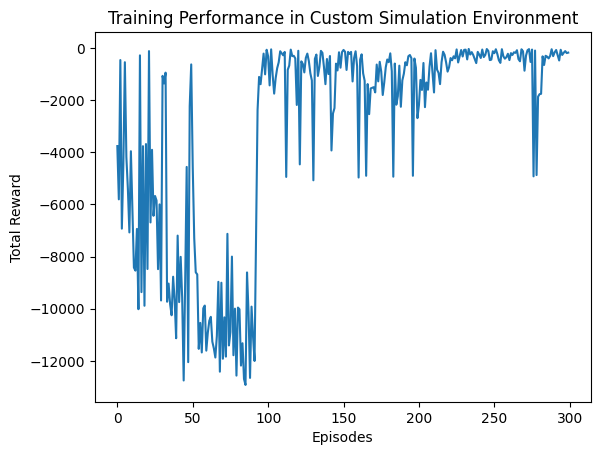

In [6]:
def train_dqn(episodes=300):
    rewards = []
    gamma = 0.95
    epsilon, eps_min, eps_decay = 1.0, 0.05, 0.995

    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0.0

        for _ in range(200):
            s = torch.tensor(state, dtype=torch.float32)
            q_values = agent(s)

            if np.random.rand() < epsilon:
                action = random.choice([0, 1, 2])
            else:
                action = torch.argmax(q_values).item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            with torch.no_grad():
                q_next = agent(torch.tensor(next_state, dtype=torch.float32))
                target_value = reward if done else reward + gamma * torch.max(q_next).item()

            target_q = q_values.detach().clone()
            target_q[action] = target_value

            loss = criterion(q_values, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_reward += reward
            state = next_state
            if done:
                break

        epsilon = max(eps_min, epsilon * eps_decay)
        rewards.append(total_reward)

    return rewards

results = train_dqn(300)
plt.plot(results)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Training Performance in Custom Simulation Environment")
plt.show()
